In [1]:
import os, yaml, sys
import numpy as np
from sklearn.decomposition import IncrementalPCA
from torchvision.models.feature_extraction import create_feature_extractor
import torch
import cv2
import joblib
import matplotlib.pyplot as plt
import time
from einops import rearrange
from IPython.display import clear_output
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["useful_stuff_path"])
sys.path.append(paths["src_path"])
from useful_stuff.general_utils.utils import print_wise, is_empty, get_device
from useful_stuff.image_processing.utils import get_video_dimensions, read_video
from useful_stuff.image_processing.computational_models import get_relevant_output_layers, imgANN
# from image_processing.utils import concatenate_frames_batch, shuffle_frames
from image_processing.gaze_dep_models import preprocess_batch, extract_center_patches, sample_random_patches, capture_1917_movie_runs, extract_features_1917_movie, ipca_movie_patches, save_ipca_patch


In [27]:
from dataclasses import dataclass, field

device = 'mps'
@dataclass
class Cfg:
    sq_size = 384
    input_size = 384
    secs_to_skip = 5
    batch_size = 100
    patches_per_frame = 3
    frames_step = 3 # every how many frames we want to take a sample (due to high temporal autocorrelation we can skip)
    patches_overhead_sampling = 2 # how many patches we want more than the images we're gonna pass to the model (to avoid proper shuffling)
    tot_patches = 3
    n_components = 1000
    layer_idx = 23
    model_name = 'dino_v3_l'
    pkg = 'hf'
    pooling = "all"
    model_url = "facebook/dinov3-vitl16-pretrain-lvd1689m"
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
print(layers)

['layer.0.mlp.down_proj', 'layer.1.mlp.down_proj', 'layer.2.mlp.down_proj', 'layer.3.mlp.down_proj', 'layer.4.mlp.down_proj', 'layer.5.mlp.down_proj', 'layer.6.mlp.down_proj', 'layer.7.mlp.down_proj', 'layer.8.mlp.down_proj', 'layer.9.mlp.down_proj', 'layer.10.mlp.down_proj', 'layer.11.mlp.down_proj', 'layer.12.mlp.down_proj', 'layer.13.mlp.down_proj', 'layer.14.mlp.down_proj', 'layer.15.mlp.down_proj', 'layer.16.mlp.down_proj', 'layer.17.mlp.down_proj', 'layer.18.mlp.down_proj', 'layer.19.mlp.down_proj', 'layer.20.mlp.down_proj', 'layer.21.mlp.down_proj', 'layer.22.mlp.down_proj', 'layer.23.mlp.down_proj']


In [22]:
m = imgANN(cfg.model_name, cfg.pkg, cfg.pooling, repo_url=cfg.model_url, dtype=torch.float32)

11:43:12 - device being used: mps


In [28]:
fn = save_ipca_patch(paths, cfg.model_name, layers[cfg.layer_idx], cfg.n_components, cfg.sq_size, cfg.pooling)
print(fn)
ipca_obj = joblib.load(fn)


/Users/tizianocausin/1917_local/models/dino_v3_l_layer.23.mlp.down_proj_1000components_384x384patch_allpool.pkl


In [36]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
m.create_forward_hook([layers[cfg.layer_idx]])
torch.cuda.empty_cache()
caps_list = capture_1917_movie_runs(paths)
fps = caps_list[0].get(cv2.CAP_PROP_FPS)
tot_frames = []
for start_f in [1500,]:
    start_s = start_f/fps
    for cap in caps_list:
        end_f = start_f+500
        end_s = end_f/fps
        v = read_video(paths, None, cap=cap, start=start_s, end=end_s, release=False, verbose=False)
        v = v[::cfg.frames_step*10]
        v = extract_center_patches(v, cfg.sq_size)
        if tot_frames is None:
            tot_frames = v
        else:
            tot_frames.extend(v)# = torch.concatenate((tot_frames, v), dim=0)
        # end if tot_frames is None:
    chunk = sample_random_patches(tot_frames, 100)
preproc_chunk = preprocess_batch(chunk, cfg.input_size, device=device)

with torch.no_grad():
    m.model(preproc_chunk)


pts = m.features[layers[cfg.layer_idx]].detach().cpu().numpy() @ ipca_obj.components_.T

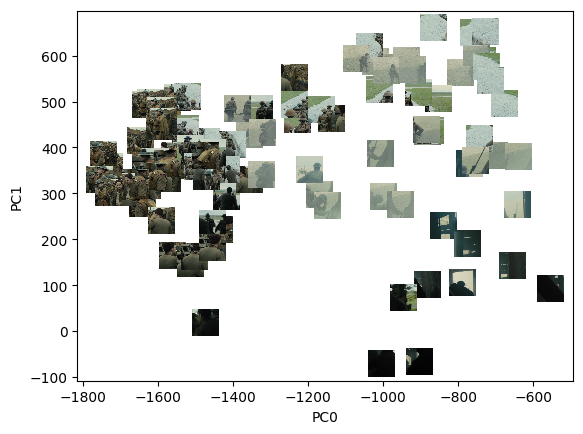

In [37]:
fig, ax = plt.subplots()

# scatter points (optional, for reference)
dims = (0,1)
ax.scatter(pts[:, dims[0]], pts[:, dims[1]])
ax.set_xlabel(f"PC{dims[0]}")
ax.set_ylabel(f"PC{dims[1]}")

# overlay images
for i in range(pts.shape[0]):
    # ensure image is in (H, W, C) and in [0,1] or [0,255]
    x = pts[i, dims[0]]
    y = pts[i, dims[1]]
    c = chunk[i, :].detach().cpu().numpy()
    # m = np.abs(c).max()
    # c_min, c_max = c.min(), c.max()
    # img = (c - c_min) / (c_max - c_min + 1e-8)
    # img = c.transpose(1,2,0)
    image = OffsetImage(c, zoom=0.05, alpha=1)

    ab = AnnotationBbox(image, (x, y), frameon=False)
    ax.add_artist(ab)
plt.show()

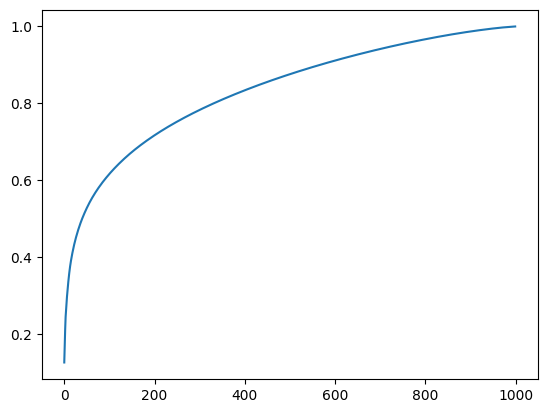

In [31]:
plt.plot(np.cumsum(ipca_obj.explained_variance_ratio_))

# TODO do this also for already extracted and projected features